<a href="https://colab.research.google.com/github/kanny789/ddo-data-dev/blob/main/AutoEndoder_CC_Anomaly_Detection_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql.functions import col, count, sum, window, expr, floor
from pyspark.sql.functions import explode_outer
from pyspark.sql.functions import col, log1p
from pyspark.sql.window import Window
from pyspark.sql.functions import log1p
from pyspark.sql.functions import sum as _sum, count
%pip install kagglehub[pandas-datasets]

In [2]:
# Load the latest version
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_834/3638448700.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [3]:
import pandas as pd
import numpy as np

# Drop duplicates
df = df.drop_duplicates()

# Cast columns
df["Time"] = df["Time"].astype(float)
df["Amount"] = df["Amount"].astype(float)
df["Class"] = df["Class"].astype(int)

for i in range(1, 29):
    df[f"V{i}"] = df[f"V{i}"].astype(float)

silver_clean = df.copy()
silver_clean["HourOfDay"] = np.floor(silver_clean["Time"] / 3600) % 24
silver_clean["HourOfDay"] = silver_clean["HourOfDay"].astype(int)

silver_clean["IsNight"] = ((silver_clean["HourOfDay"] < 6) |
                           (silver_clean["HourOfDay"] > 22)).astype(int)

silver_time = silver_clean.copy()
silver_clean["Amount_log"] = np.log1p(silver_clean["Amount"])
silver_amount =silver_clean.copy()
# Ensure data is sorted by Time (Spark Window.orderBy)
silver_amount = silver_amount.sort_values("Time").reset_index(drop=True)

# Previous Time
silver_amount["PrevTime"] = silver_amount["Time"].shift(1)

# Time since previous
silver_amount["TimeSincePrev"] = silver_amount["Time"] - silver_amount["PrevTime"]

# Previous Amount
silver_amount["PrevAmount"] = silver_amount["Amount"].shift(1)

# Amount difference
silver_amount["AmountDiff"] = (silver_amount["Amount"] - silver_amount["PrevAmount"]).round(2)

# Amount ratio (safe divide)
silver_amount["AmountRatio"] = (silver_amount["Amount"] / silver_amount["PrevAmount"]).replace([np.inf, -np.inf], np.nan).round(2)


In [4]:
# Define feature columns
feature_cols = [f"V{i}" for i in range(1, 29)] + [
    "Amount_log", "HourOfDay", "IsNight",
    "TimeSincePrev", "AmountDiff", "AmountRatio"
]

# Select only the relevant columns (Class + features)
df_sel = silver_amount[["Class"] + feature_cols]

# Drop rows with NaN in any of the feature columns
df_sel = df_sel.dropna(subset=feature_cols)

# Count rows
print("Rows:", len(df_sel))

Rows: 281917


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Impute missing numeric values with median

y = df_sel["Class"].astype(int)
X = df_sel.drop(columns=["Class"])


# Standardize features
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# --- Impute using TRAIN ONLY ---
median_vals = X_train_full.median()

X_train_full = X_train_full.fillna(median_vals)
X_val = X_val.fillna(median_vals)
X_test = X_test.fillna(median_vals)

# --- Train only on normal samples ---
X_train = X_train_full[y_train_full == 0]

# --- Scale using TRAIN ONLY ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

/tmp/ipykernel_834/3412405245.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


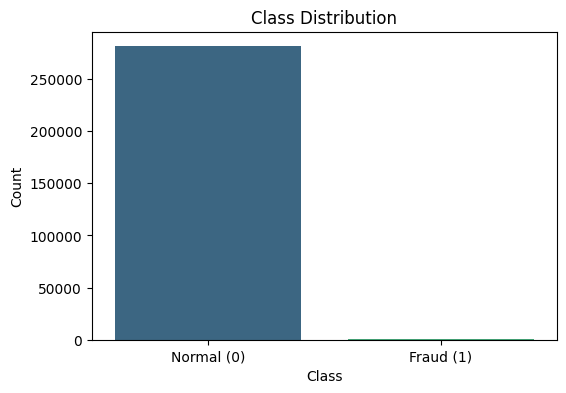

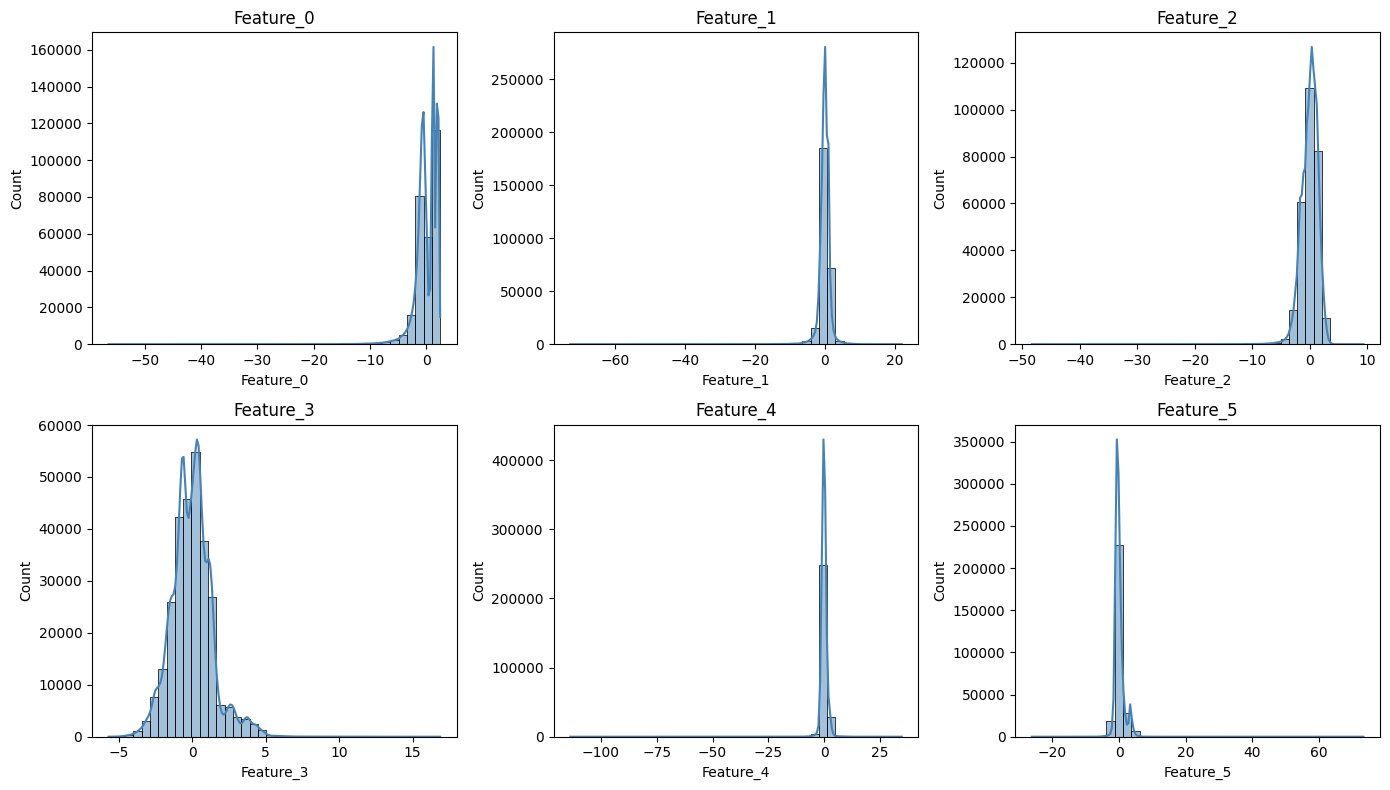

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# count plot
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks([0,1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

#feature plot
import matplotlib.pyplot as plt
import seaborn as sns

df = X.copy()
df.columns = [f"Feature_{i}" for i in range(df.shape[1])]

# Select first 6 features for snapshot
sample_features = df.iloc[:, :6]

plt.figure(figsize=(14,8))
for i, col in enumerate(sample_features.columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(sample_features[col], bins=40, kde=True, color="steelblue")
    plt.title(col)

plt.tight_layout()
plt.show()

**AutoEncoder Architecture 1**

In [22]:
from tensorflow.keras import layers, models

# ----- Model name: BASELINE AE -----
input_dim = X_train.shape[1]
encoding_dim_base = 4   # baseline bottleneck

# ----- Encoder -----
inp_base = layers.Input(shape=(input_dim,), name="input_base")
x_base = layers.Dense(encoding_dim_base * 2, activation="relu", name="enc_dense1_base")(inp_base)
latent_base = layers.Dense(encoding_dim_base, activation="relu", name="latent_base")(x_base)

# ----- Decoder -----
x_base_dec = layers.Dense(encoding_dim_base * 2, activation="relu", name="dec_dense1_base")(latent_base)
out_base = layers.Dense(input_dim, activation="linear", name="output_base")(x_base_dec)

# ----- Models -----
ae_base = models.Model(inputs=inp_base, outputs=out_base, name="Autoencoder_Base")
ae_base.compile(optimizer="adam", loss="mse")

enc_base = models.Model(inputs=inp_base, outputs=latent_base, name="Encoder_Base")

# ----- Summary -----
ae_base.summary()

Model: "Autoencoder_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_base (InputLayer)         │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1_base (Dense)         │ (None, 8)              │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_base (Dense)             │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1_base (Dense)         │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_base (Dense)             │ (None, 34)             │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
import tensorflow as tf
history = ae_base.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9022 - val_loss: 0.8292
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8107 - val_loss: 0.7714
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7658 - val_loss: 0.7487
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7499 - val_loss: 0.7386
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7420 - val_loss: 0.7336
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7379 - val_loss: 0.7311
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7354 - val_loss: 0.7289
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7335 - val_loss: 0.7271
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7319 - val_loss: 0.7256
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7305 - val_loss: 0.7240
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7291 - val_loss: 0.7228
Epoch 12/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [24]:
import numpy as np

# Get reconstructions for the validation set
recon_base = ae_base.predict(X_val)

# Compute reconstruction error
errors_base = np.mean(np.square(X_val - recon_base), axis=1)

# Choose threshold
threshold_base = np.percentile(errors_base, 99.5)

# Flag anomalies
anomaly_flags_base = errors_base > threshold_base

# Evaluate using validation labels
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score

precision_base, recall_base, _ = precision_recall_curve(y_val, errors_base)
auprc_base = auc(recall_base, precision_base)

preds_base = (errors_base > threshold_base).astype(int)

print("AUPRC (Base AE):", auprc_base)
print("Threshold:", threshold_base)
print("Precision:", precision_score(y_val, preds_base))
print("Recall:", recall_score(y_val, preds_base))
print("F1:", f1_score(y_val, preds_base))

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
AUPRC (Base AE): 0.1441469856702693
Threshold: 7.571348173446861
Precision: 0.15566037735849056
Recall: 0.4647887323943662
F1: 0.2332155477031802


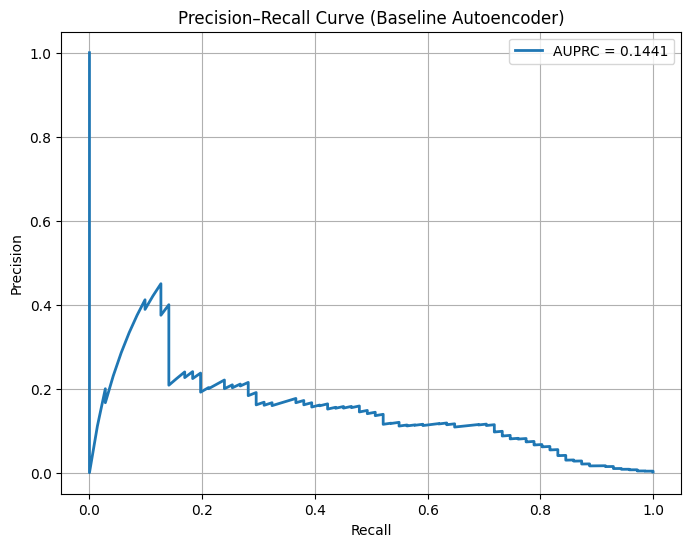

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute precision–recall values
precision_base, recall_base, _ = precision_recall_curve(y_val, errors_base)

# Compute AUPRC
auprc_base = auc(recall_base, precision_base)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f'AUPRC = {auprc_base:.4f}', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Baseline Autoencoder)')
plt.legend()
plt.grid(True)
plt.show()

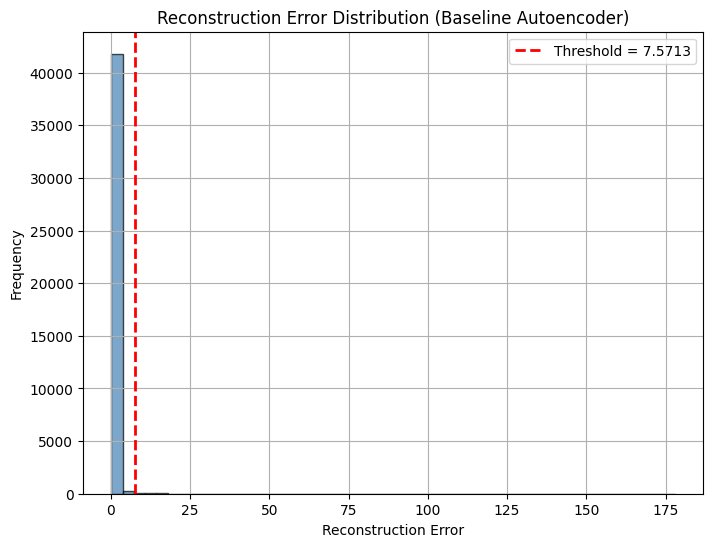

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Histogram of reconstruction errors
plt.hist(errors_base, bins=50, alpha=0.7, color='steelblue', edgecolor='black')

# Threshold line
plt.axvline(threshold_base, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {threshold_base:.4f}")

plt.title("Reconstruction Error Distribution (Baseline Autoencoder)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

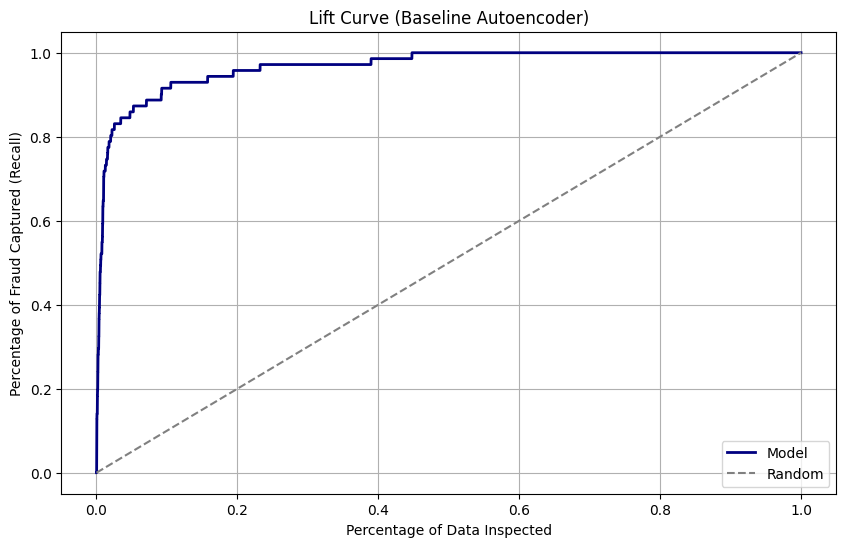

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Convert y_val to numpy array for positional indexing
y_val_np = np.array(y_val)

# Sort by model score (descending: highest error = most anomalous)
sorted_idx = np.argsort(errors_base)[::-1]
sorted_labels = y_val_np[sorted_idx]

# Cumulative positives found
cumulative_positives = np.cumsum(sorted_labels)

# Total positives in dataset
total_positives = cumulative_positives[-1]

# Percentage of data inspected
percent_inspected = np.arange(1, len(y_val_np) + 1) / len(y_val_np)

# Model recall at each point
model_recall = cumulative_positives / total_positives

# Random model line (baseline)
random_recall = percent_inspected

# Plot
plt.figure(figsize=(10, 6))
plt.plot(percent_inspected, model_recall, label="Model", linewidth=2, color="navy")
plt.plot(percent_inspected, random_recall, label="Random", linestyle="--", color="gray")

plt.title("Lift Curve (Baseline Autoencoder)")
plt.xlabel("Percentage of Data Inspected")
plt.ylabel("Percentage of Fraud Captured (Recall)")
plt.grid(True)
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


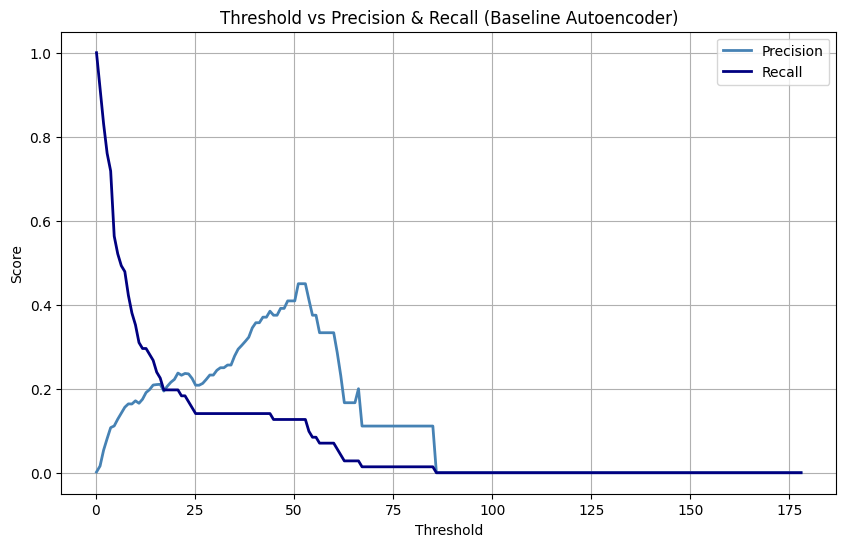

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Use evenly spaced thresholds between min and max error
num_points = 200
thresholds = np.linspace(errors_base.min(), errors_base.max(), num_points)

precisions = []
recalls = []

for t in thresholds:
    preds = (errors_base > t).astype(int)
    precisions.append(precision_score(y_val, preds))
    recalls.append(recall_score(y_val, preds))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", linewidth=2)
plt.plot(thresholds, recalls, label="Recall", color="navy", linewidth=2)

plt.title("Threshold vs Precision & Recall (Baseline Autoencoder)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()



**Deeper Dense Autoencoder**
Does adding depth (more layers) and a tighter bottleneck improve anomaly separation for credit‑card fraud?
This version:
Adds more encoder layers
Uses a tighter bottleneck (4 dims)
Mirrors the encoder in the decoder
Keeps everything fully connected (fair comparison with baseline)
Uses ReLU activations and linear output

In [7]:
from tensorflow.keras import layers, models

# ----- DEEP AUTOENCODER -----

input_dim = X_train.shape[1]
encoding_dim_deep = 4   # same bottleneck as baseline for fair comparison

# ----- Encoder -----
inp_deep = layers.Input(shape=(input_dim,), name="input_deep")
x_deep = layers.Dense(32, activation="relu", name="enc_dense1_deep")(inp_deep)
x_deep = layers.Dense(16, activation="relu", name="enc_dense2_deep")(x_deep)
latent_deep = layers.Dense(encoding_dim_deep, activation="relu", name="latent_deep")(x_deep)

# ----- Decoder -----
x_deep_dec = layers.Dense(16, activation="relu", name="dec_dense1_deep")(latent_deep)
x_deep_dec = layers.Dense(32, activation="relu", name="dec_dense2_deep")(x_deep_dec)
out_deep = layers.Dense(input_dim, activation="linear", name="output_deep")(x_deep_dec)

# ----- Models -----
ae_deep = models.Model(inputs=inp_deep, outputs=out_deep, name="Autoencoder_Deep")
ae_deep.compile(optimizer="adam", loss="mse")

enc_deep = models.Model(inputs=inp_deep, outputs=latent_deep, name="Encoder_Deep")

# ----- Summary -----
ae_deep.summary()

Model: "Autoencoder_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_deep (InputLayer)         │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1_deep (Dense)         │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense2_deep (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_deep (Dense)             │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1_deep (Dense)         │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2_deep (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_deep (Dense)             │ (None, 34)             │         1,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,462 (13.52 KB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import tensorflow as tf
history = ae_deep.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.8022 - val_loss: 0.6841
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6540 - val_loss: 0.6281
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6083 - val_loss: 0.5952
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5790 - val_loss: 0.5783
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5601 - val_loss: 0.5610
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5452 - val_loss: 0.5826
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5363 - val_loss: 0.5389
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5276 - val_loss: 0.5311
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5210 - val_loss: 0.5254
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5155 - val_loss: 0.5215
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5097 - val_loss: 0.5161
Epoch 12/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [9]:
import numpy as np

# ----- Reconstructions for validation -----
recon_deep = ae_deep.predict(X_val)

# ----- Reconstruction error -----
errors_deep = np.mean(np.square(X_val - recon_deep), axis=1)

# ----- Threshold (99.5 percentile) -----
threshold_deep = np.percentile(errors_deep, 99.5)

# ----- Flag anomalies -----
anomaly_flags_deep = errors_deep > threshold_deep

# ----- Evaluation -----
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score

precision_deep, recall_deep, _ = precision_recall_curve(y_val, errors_deep)
auprc_deep = auc(recall_deep, precision_deep)

preds_deep = (errors_deep > threshold_deep).astype(int)

print("AUPRC (Deep AE):", auprc_deep)
print("Threshold:", threshold_deep)
print("Precision:", precision_score(y_val, preds_deep))
print("Recall:", recall_score(y_val, preds_deep))
print("F1:", f1_score(y_val, preds_deep))


1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
AUPRC (Deep AE): 0.41801281702950094
Threshold: 2.985913793256521
Precision: 0.24056603773584906
Recall: 0.7183098591549296
F1: 0.36042402826855124


**Deep Autoencoder Plots**
**1. Error Plot
2. Precision Recall Curve
3. Threshold vs Precision Curve
4. Lift Curve **

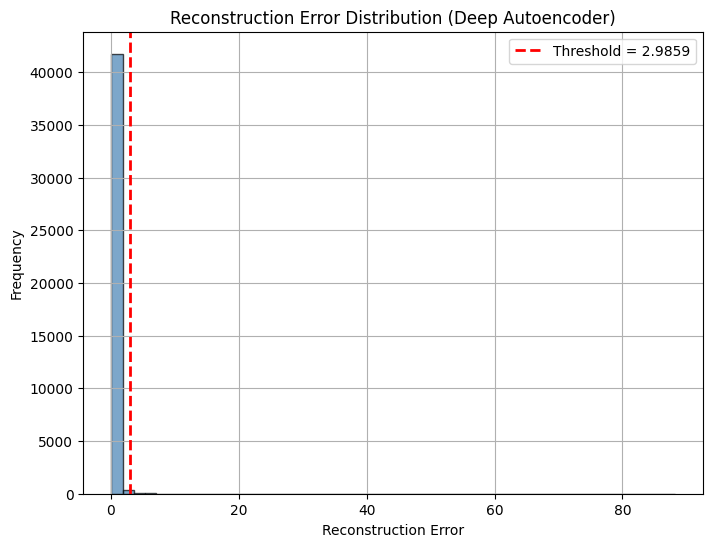

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Histogram of reconstruction errors
plt.hist(errors_deep, bins=50, alpha=0.7, color='steelblue', edgecolor='black')

# Threshold line
plt.axvline(threshold_deep, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {threshold_deep:.4f}")

plt.title("Reconstruction Error Distribution (Deep Autoencoder)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

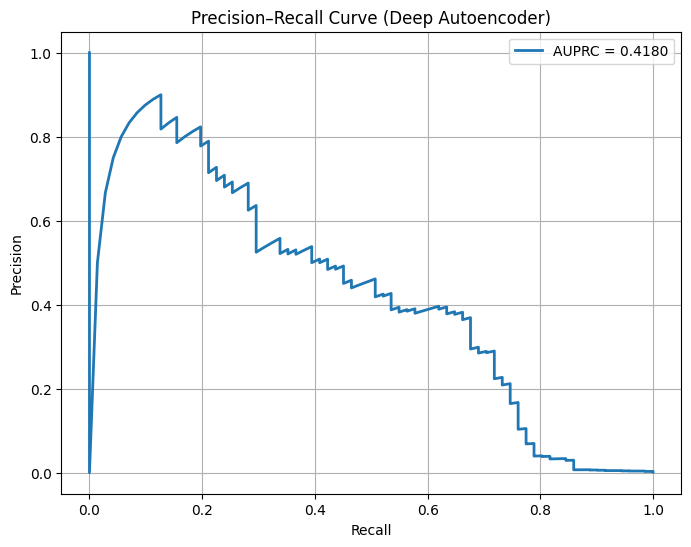

In [11]:
#precion recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute precision–recall values
precision_deep, recall_deep, _ = precision_recall_curve(y_val, errors_deep)

# Compute AUPRC
auprc_deep = auc(recall_deep, precision_deep)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_deep, precision_deep, label=f'AUPRC = {auprc_deep:.4f}', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Deep Autoencoder)')
plt.legend()
plt.grid(True)
plt.show()

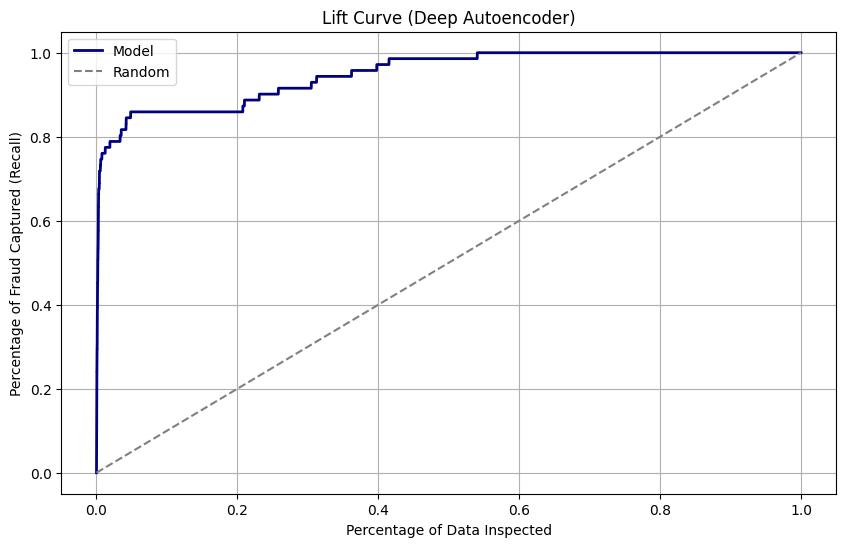

In [12]:
#Lift Curve
import numpy as np
import matplotlib.pyplot as plt

# Convert y_val to numpy array for positional indexing
y_val_np = np.array(y_val)

# Sort by model score (descending: highest error = most anomalous)
sorted_idx = np.argsort(errors_deep)[::-1]
sorted_labels = y_val_np[sorted_idx]

# Cumulative positives found
cumulative_positives = np.cumsum(sorted_labels)

# Total positives in dataset
total_positives = cumulative_positives[-1]

# Percentage of data inspected
percent_inspected = np.arange(1, len(y_val_np) + 1) / len(y_val_np)

# Model recall at each point
model_recall = cumulative_positives / total_positives

# Random model line (baseline)
random_recall = percent_inspected

# Plot
plt.figure(figsize=(10, 6))
plt.plot(percent_inspected, model_recall, label="Model", linewidth=2, color="navy")
plt.plot(percent_inspected, random_recall, label="Random", linestyle="--", color="gray")

plt.title("Lift Curve (Deep Autoencoder)")
plt.xlabel("Percentage of Data Inspected")
plt.ylabel("Percentage of Fraud Captured (Recall)")
plt.grid(True)
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


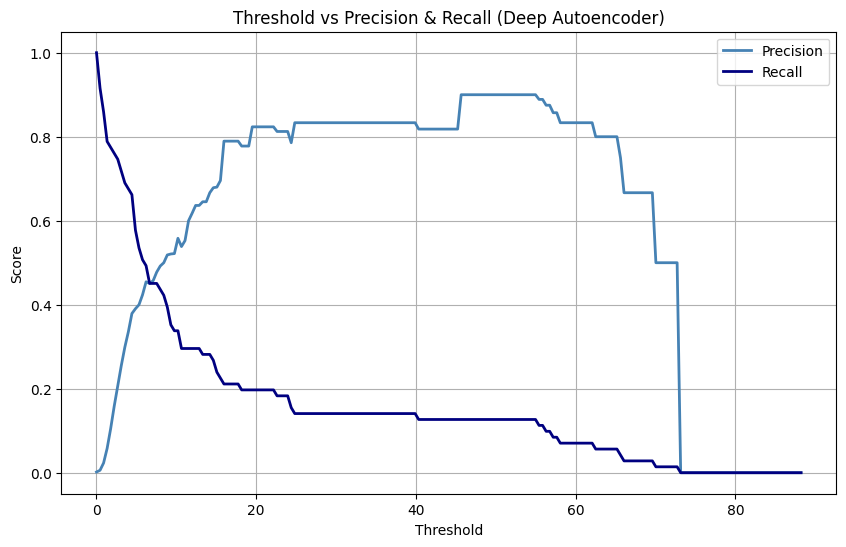

In [13]:
#Threshold vs Precision Recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Use evenly spaced thresholds between min and max error
num_points = 200
thresholds = np.linspace(errors_deep.min(), errors_deep.max(), num_points)

precisions = []
recalls = []

for t in thresholds:
    preds_deep = (errors_deep > t).astype(int)
    precisions.append(precision_score(y_val, preds_deep))
    recalls.append(recall_score(y_val, preds_deep))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", linewidth=2)
plt.plot(thresholds, recalls, label="Recall", color="navy", linewidth=2)

plt.title("Threshold vs Precision & Recall (Deep Autoencoder)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

**Sparse AutoEncoder**
Add L1 activity regularization on the bottleneck.
Encourages sparse latent codes—good for anomaly separation.

In [14]:
from tensorflow.keras import layers, models, regularizers

# ----- SPARSE AUTOENCODER -----

input_dim = X_train.shape[1]
encoding_dim_sparse = 4   # same bottleneck size for fair comparison

# ----- Encoder -----
inp_sparse = layers.Input(shape=(input_dim,), name="input_sparse")
x_sparse = layers.Dense(encoding_dim_sparse * 2, activation="relu", name="enc_dense1_sparse")(inp_sparse)

# L1 activity regularization on latent layer
latent_sparse = layers.Dense(
    encoding_dim_sparse,
    activation="relu",
    activity_regularizer=regularizers.l1(1e-5),
    name="latent_sparse"
)(x_sparse)

# ----- Decoder -----
x_sparse_dec = layers.Dense(encoding_dim_sparse * 2, activation="relu", name="dec_dense1_sparse")(latent_sparse)
out_sparse = layers.Dense(input_dim, activation="linear", name="output_sparse")(x_sparse_dec)

# ----- Models -----
ae_sparse = models.Model(inputs=inp_sparse, outputs=out_sparse, name="Autoencoder_Sparse")
ae_sparse.compile(optimizer="adam", loss="mse")

enc_sparse = models.Model(inputs=inp_sparse, outputs=latent_sparse, name="Encoder_Sparse")

# ----- Summary -----
ae_sparse.summary()


Model: "Autoencoder_Sparse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sparse (InputLayer)       │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1_sparse (Dense)       │ (None, 8)              │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_sparse (Dense)           │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1_sparse (Dense)       │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sparse (Dense)           │ (None, 34)             │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ----- Train SPARSE AE -----
history_sparse = ae_sparse.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

# ----- Reconstructions -----
recon_sparse = ae_sparse.predict(X_val)

# ----- Reconstruction error -----
errors_sparse = np.mean(np.square(X_val - recon_sparse), axis=1)

# ----- Threshold -----
threshold_sparse = np.percentile(errors_sparse, 99.5)

# ----- Evaluation -----
precision_sparse, recall_sparse, _ = precision_recall_curve(y_val, errors_sparse)
auprc_sparse = auc(recall_sparse, precision_sparse)

preds_sparse = (errors_sparse > threshold_sparse).astype(int)

print("AUPRC (Sparse AE):", auprc_sparse)
print("Threshold:", threshold_sparse)
print("Precision:", precision_score(y_val, preds_sparse))
print("Recall:", recall_score(y_val, preds_sparse))
print("F1:", f1_score(y_val, preds_sparse))


Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8807 - val_loss: 0.8016
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8016 - val_loss: 0.7774
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7781 - val_loss: 0.7564
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7590 - val_loss: 0.7410
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7464 - val_loss: 0.7323
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7394 - val_loss: 0.7274
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7348 - val_loss: 0.7232
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7310 - val_loss: 0.7201
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7281 - val_loss: 0.7174
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7259 - val_loss: 0.7156
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7244 - val_loss: 0.7143
Epoch 12/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

**Sparse AutoEncoder Plots**

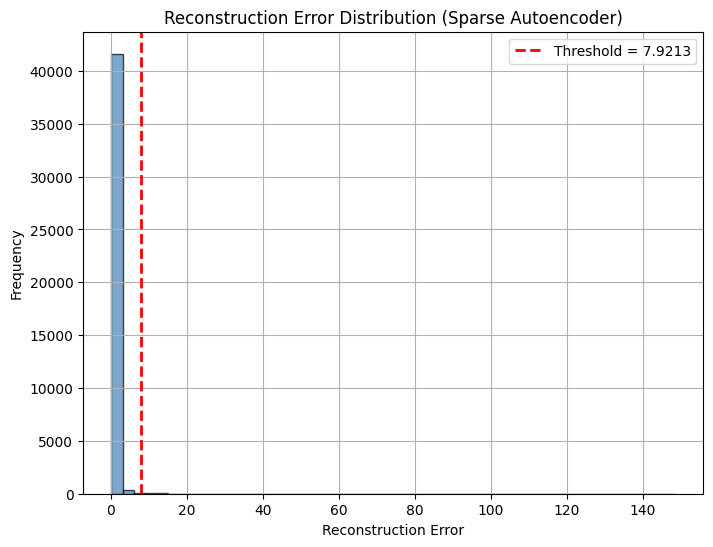

In [16]:
#error reconstruction
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Histogram of reconstruction errors
plt.hist(errors_sparse, bins=50, alpha=0.7, color='steelblue', edgecolor='black')

# Threshold line
plt.axvline(threshold_sparse, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {threshold_sparse:.4f}")

plt.title("Reconstruction Error Distribution (Sparse Autoencoder)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

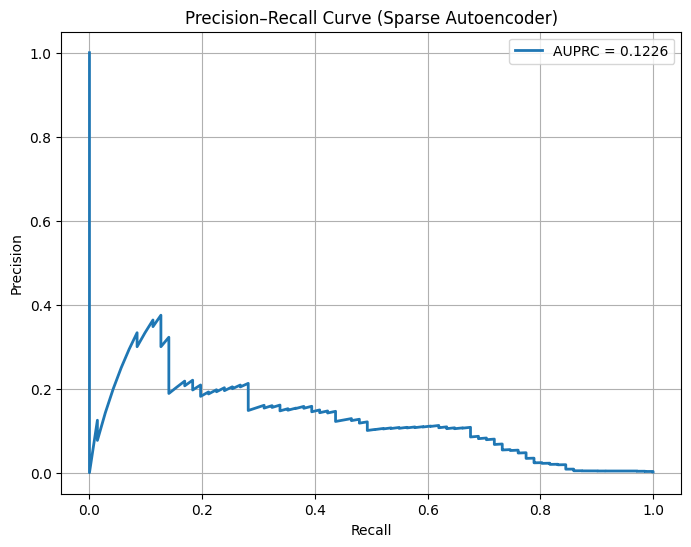

In [17]:
#precion recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute precision–recall values
precision_sparse, recall_sparse, _ = precision_recall_curve(y_val, errors_sparse)

# Compute AUPRC
auprc_sparse= auc(recall_sparse, precision_sparse)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_sparse, precision_sparse, label=f'AUPRC = {auprc_sparse:.4f}', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Sparse Autoencoder)')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


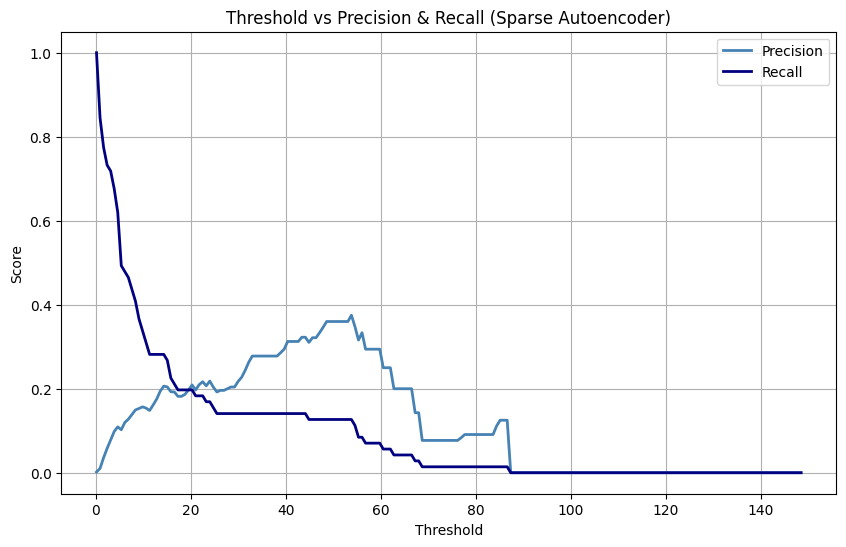

In [18]:
#threshold vs precsion recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Use evenly spaced thresholds between min and max error
num_points = 200
thresholds = np.linspace(errors_sparse.min(), errors_sparse.max(), num_points)

precisions = []
recalls = []

for t in thresholds:
    preds = (errors_sparse > t).astype(int)
    precisions.append(precision_score(y_val, preds))
    recalls.append(recall_score(y_val, preds))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", linewidth=2)
plt.plot(thresholds, recalls, label="Recall", color="navy", linewidth=2)

plt.title("Threshold vs Precision & Recall (Sparse Autoencoder)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

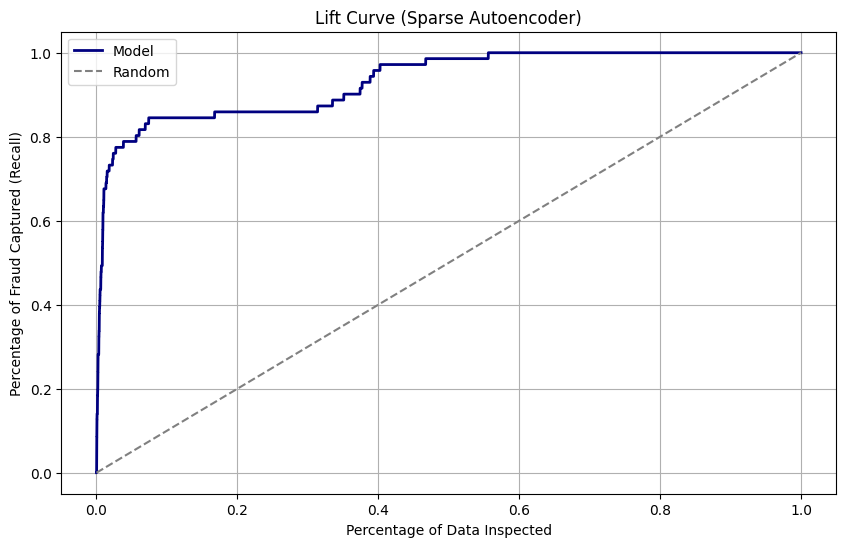

In [19]:
#Lift Curve
import numpy as np
import matplotlib.pyplot as plt

# Convert y_val to numpy array for positional indexing
y_val_np = np.array(y_val)

# Sort by model score (descending: highest error = most anomalous)
sorted_idx = np.argsort(errors_sparse)[::-1]
sorted_labels = y_val_np[sorted_idx]

# Cumulative positives found
cumulative_positives = np.cumsum(sorted_labels)

# Total positives in dataset
total_positives = cumulative_positives[-1]

# Percentage of data inspected
percent_inspected = np.arange(1, len(y_val_np) + 1) / len(y_val_np)

# Model recall at each point
model_recall = cumulative_positives / total_positives

# Random model line (baseline)
random_recall = percent_inspected

# Plot
plt.figure(figsize=(10, 6))
plt.plot(percent_inspected, model_recall, label="Model", linewidth=2, color="navy")
plt.plot(percent_inspected, random_recall, label="Random", linestyle="--", color="gray")

plt.title("Lift Curve (Sparse Autoencoder)")
plt.xlabel("Percentage of Data Inspected")
plt.ylabel("Percentage of Fraud Captured (Recall)")
plt.grid(True)
plt.legend()
plt.show()

**Denoising AutoEncoder**

In [20]:
from tensorflow.keras import layers, models

# ----- DENOISING AUTOENCODER -----

input_dim = X_train.shape[1]
encoding_dim_denoise = 4   # same bottleneck size for fair comparison

# ----- Encoder -----
inp_denoise = layers.Input(shape=(input_dim,), name="input_denoise")

# Add Gaussian noise to input
noisy_input = layers.GaussianNoise(0.1, name="gaussian_noise")(inp_denoise)

x_denoise = layers.Dense(encoding_dim_denoise * 2, activation="relu", name="enc_dense1_denoise")(noisy_input)
latent_denoise = layers.Dense(encoding_dim_denoise, activation="relu", name="latent_denoise")(x_denoise)

# ----- Decoder -----
x_denoise_dec = layers.Dense(encoding_dim_denoise * 2, activation="relu", name="dec_dense1_denoise")(latent_denoise)
out_denoise = layers.Dense(input_dim, activation="linear", name="output_denoise")(x_denoise_dec)

# ----- Models -----
ae_denoise = models.Model(inputs=inp_denoise, outputs=out_denoise, name="Autoencoder_Denoise")
ae_denoise.compile(optimizer="adam", loss="mse")

enc_denoise = models.Model(inputs=inp_denoise, outputs=latent_denoise, name="Encoder_Denoise")

# ----- Summary -----
ae_denoise.summary()


Model: "Autoencoder_Denoise"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_denoise (InputLayer)      │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1_denoise (Dense)      │ (None, 8)              │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_denoise (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1_denoise (Dense)      │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_denoise (Dense)          │ (None, 34)             │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_denoise = ae_denoise.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

recon_denoise = ae_denoise.predict(X_val)
errors_denoise = np.mean(np.square(X_val - recon_denoise), axis=1)
threshold_denoise = np.percentile(errors_denoise, 99.5)

precision_denoise, recall_denoise, _ = precision_recall_curve(y_val, errors_denoise)
auprc_denoise = auc(recall_denoise, precision_denoise)

preds_denoise = (errors_denoise > threshold_denoise).astype(int)

print("AUPRC (Denoising AE):", auprc_denoise)
print("Precision:", precision_score(y_val, preds_denoise))
print("Recall:", recall_score(y_val, preds_denoise))
print("F1:", f1_score(y_val, preds_denoise))


Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8962 - val_loss: 0.8043
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7844 - val_loss: 0.7555
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7591 - val_loss: 0.7394
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7483 - val_loss: 0.7320
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7435 - val_loss: 0.7283
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7408 - val_loss: 0.7267
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7389 - val_loss: 0.7261
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7374 - val_loss: 0.7234
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7360 - val_loss: 0.7221
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7346 - val_loss: 0.7209
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7334 - val_loss: 0.7204
Epoch 12/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

**Denoising AE plots**

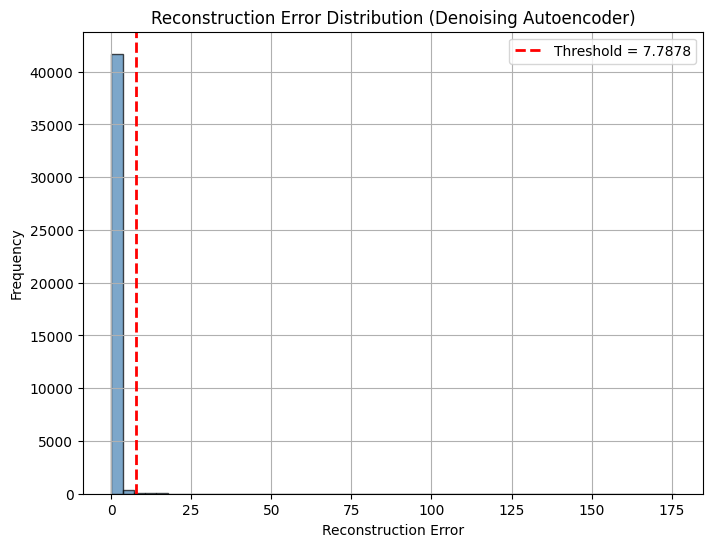

In [22]:
#error reconstruction
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Histogram of reconstruction errors
plt.hist(errors_denoise, bins=50, alpha=0.7, color='steelblue', edgecolor='black')

# Threshold line
plt.axvline(threshold_denoise, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {threshold_denoise:.4f}")

plt.title("Reconstruction Error Distribution (Denoising Autoencoder)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

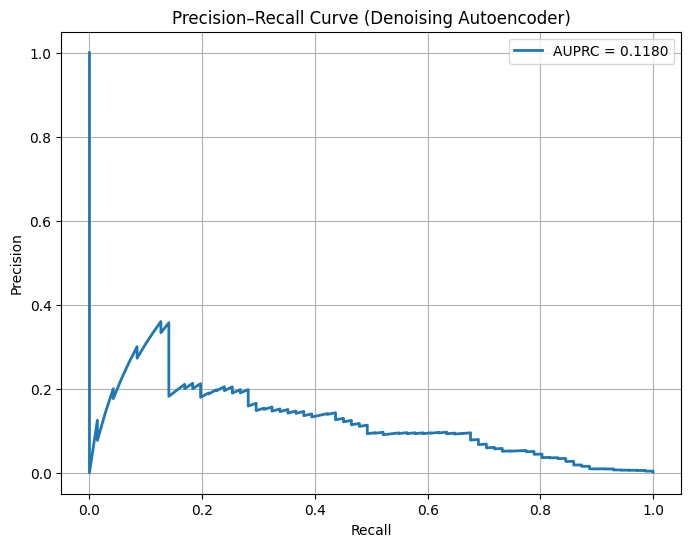

In [23]:
#precion recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute precision–recall values
precision_denoise, recall_denoise, _ = precision_recall_curve(y_val, errors_denoise)

# Compute AUPRC
auprc_denoise= auc(recall_denoise, precision_denoise)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_denoise, precision_denoise, label=f'AUPRC = {auprc_denoise:.4f}', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Denoising Autoencoder)')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


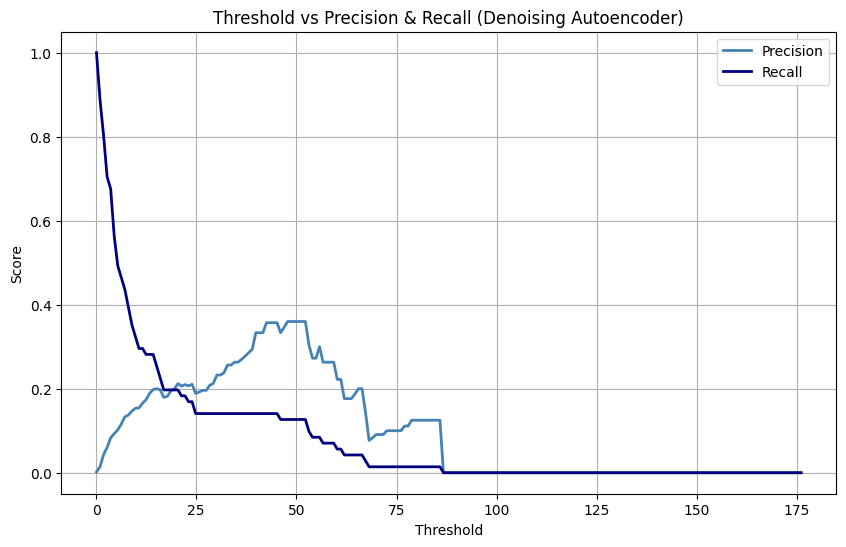

In [24]:
#threshold vs precsion recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Use evenly spaced thresholds between min and max error
num_points = 200
thresholds = np.linspace(errors_denoise.min(), errors_denoise.max(), num_points)

precisions = []
recalls = []

for t in thresholds:
    preds = (errors_denoise > t).astype(int)
    precisions.append(precision_score(y_val, preds))
    recalls.append(recall_score(y_val, preds))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", linewidth=2)
plt.plot(thresholds, recalls, label="Recall", color="navy", linewidth=2)

plt.title("Threshold vs Precision & Recall (Denoising Autoencoder)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

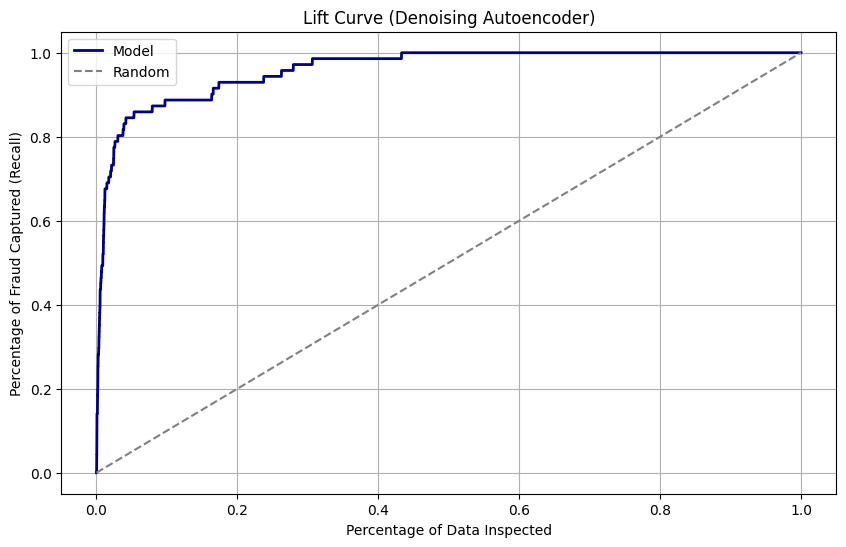

In [25]:
#Lift Curve
import numpy as np
import matplotlib.pyplot as plt

# Convert y_val to numpy array for positional indexing
y_val_np = np.array(y_val)

# Sort by model score (descending: highest error = most anomalous)
sorted_idx = np.argsort(errors_denoise)[::-1]
sorted_labels = y_val_np[sorted_idx]

# Cumulative positives found
cumulative_positives = np.cumsum(sorted_labels)

# Total positives in dataset
total_positives = cumulative_positives[-1]

# Percentage of data inspected
percent_inspected = np.arange(1, len(y_val_np) + 1) / len(y_val_np)

# Model recall at each point
model_recall = cumulative_positives / total_positives

# Random model line (baseline)
random_recall = percent_inspected

# Plot
plt.figure(figsize=(10, 6))
plt.plot(percent_inspected, model_recall, label="Model", linewidth=2, color="navy")
plt.plot(percent_inspected, random_recall, label="Random", linestyle="--", color="gray")

plt.title("Lift Curve (Denoising Autoencoder)")
plt.xlabel("Percentage of Data Inspected")
plt.ylabel("Percentage of Fraud Captured (Recall)")
plt.grid(True)
plt.legend()
plt.show()

**Variational AutoEncoder**

In [26]:
from tensorflow.keras import layers, models
import tensorflow as tf

# ----- VARIATIONAL AUTOENCODER -----

input_dim = X_train.shape[1]
latent_dim = 4

# ----- Encoder -----
inp_vae = layers.Input(shape=(input_dim,), name="input_vae")
x = layers.Dense(16, activation="relu")(inp_vae)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sampling, name="latent_vae")([z_mean, z_log_var])

encoder_vae = models.Model(inp_vae, [z_mean, z_log_var, z], name="Encoder_VAE")

# ----- Decoder -----
latent_inputs = layers.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(16, activation="relu")(latent_inputs)
out = layers.Dense(input_dim, activation="linear")(x)

decoder_vae = models.Model(latent_inputs, out, name="Decoder_VAE")

# ----- VAE Model (Subclassed for custom loss) -----
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(tf.square(inputs - reconstructed))

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        # Total loss
        total_loss = recon_loss + kl_loss
        self.add_loss(total_loss)

        return reconstructed

vae = VAE(encoder_vae, decoder_vae)
vae.compile(optimizer="adam")

vae.summary()


Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder_VAE (Functional)        │ ((None, 4), (None, 4), │           696 │
│                                 │ (None, 4))             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_VAE (Functional)        │ (None, 34)             │           658 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354 (5.29 KB)

 Trainable params: 1,354 (5.29 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_vae = vae.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

recon_vae = vae.predict(X_val)
errors_vae = np.mean(np.square(X_val - recon_vae), axis=1)
threshold_vae = np.percentile(errors_vae, 99.5)

precision_vae, recall_vae, _ = precision_recall_curve(y_val, errors_vae)
auprc_vae = auc(recall_vae, precision_vae)

preds_vae = (errors_vae > threshold_vae).astype(int)

print("AUPRC (VAE):", auprc_vae)
print("Precision:", precision_score(y_val, preds_vae))
print("Recall:", recall_score(y_val, preds_vae))
print("F1:", f1_score(y_val, preds_vae))


Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 10647746.0000 - val_loss: 5.1480
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 684.7927 - val_loss: 2.0730
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 44.4151 - val_loss: 1.8933
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 44.7873 - val_loss: 1.7253
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 36.3590 - val_loss: 1.5916
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 31.0414 - val_loss: 1.4441
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 27.6100 - val_loss: 1.3637
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.8528 - val_loss: 1.3163
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 20.8358 - val_loss: 1.2750
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 21.6400 - val_loss: 1.2386
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.9204 - val_loss: 1.2030
Epoch 12/50
770/770 ━━━━━━━━━━━━━━

VAE Plots

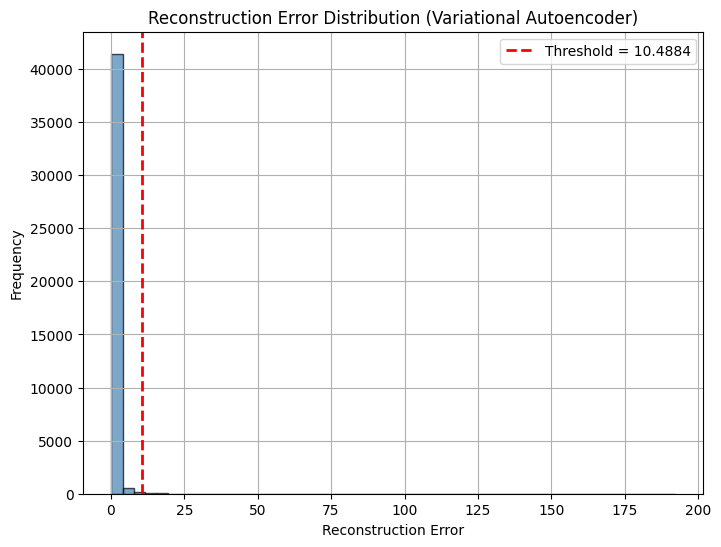

In [28]:
#error reconstruction
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Histogram of reconstruction errors
plt.hist(errors_vae, bins=50, alpha=0.7, color='steelblue', edgecolor='black')

# Threshold line
plt.axvline(threshold_vae, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {threshold_vae:.4f}")

plt.title("Reconstruction Error Distribution (Variational Autoencoder)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

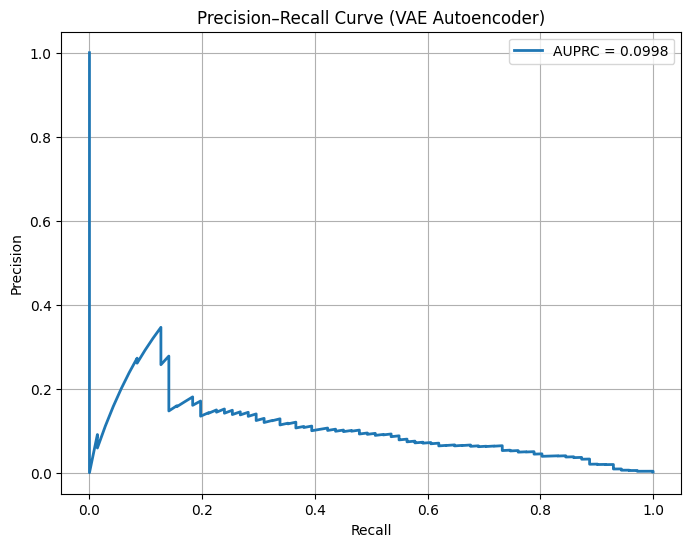

In [30]:
# Compute precision–recall values
precision_vae, recall_vae, thresholds_vae = precision_recall_curve(y_val, errors_vae)

# Compute AUPRC
auprc_vae = auc(recall_vae, precision_vae)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vae, precision_vae, label=f'AUPRC = {auprc_vae:.4f}', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (VAE Autoencoder)')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


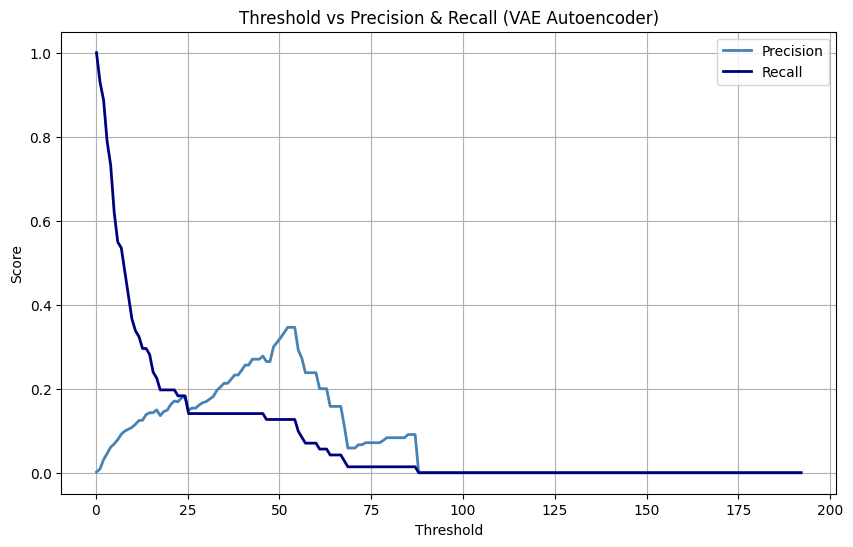

In [31]:
#threshold vs precsion recall
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Use evenly spaced thresholds between min and max error
num_points = 200
thresholds = np.linspace(errors_vae.min(), errors_vae.max(), num_points)

precisions = []
recalls = []

for t in thresholds:
    preds = (errors_vae > t).astype(int)
    precisions.append(precision_score(y_val, preds))
    recalls.append(recall_score(y_val, preds))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", linewidth=2)
plt.plot(thresholds, recalls, label="Recall", color="navy", linewidth=2)

plt.title("Threshold vs Precision & Recall (VAE Autoencoder)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

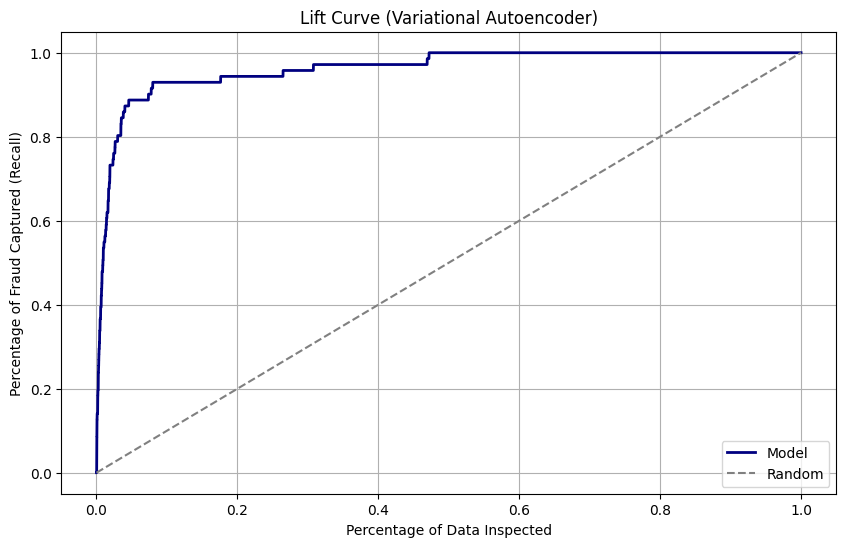

In [32]:
#Lift Curve
import numpy as np
import matplotlib.pyplot as plt

# Convert y_val to numpy array for positional indexing
y_val_np = np.array(y_val)

# Sort by model score (descending: highest error = most anomalous)
sorted_idx = np.argsort(errors_vae)[::-1]
sorted_labels = y_val_np[sorted_idx]

# Cumulative positives found
cumulative_positives = np.cumsum(sorted_labels)

# Total positives in dataset
total_positives = cumulative_positives[-1]

# Percentage of data inspected
percent_inspected = np.arange(1, len(y_val_np) + 1) / len(y_val_np)

# Model recall at each point
model_recall = cumulative_positives / total_positives

# Random model line (baseline)
random_recall = percent_inspected

# Plot
plt.figure(figsize=(10, 6))
plt.plot(percent_inspected, model_recall, label="Model", linewidth=2, color="navy")
plt.plot(percent_inspected, random_recall, label="Random", linestyle="--", color="gray")

plt.title("Lift Curve (Variational Autoencoder)")
plt.xlabel("Percentage of Data Inspected")
plt.ylabel("Percentage of Fraud Captured (Recall)")
plt.grid(True)
plt.legend()
plt.show()